# Extended Data Figure 11

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

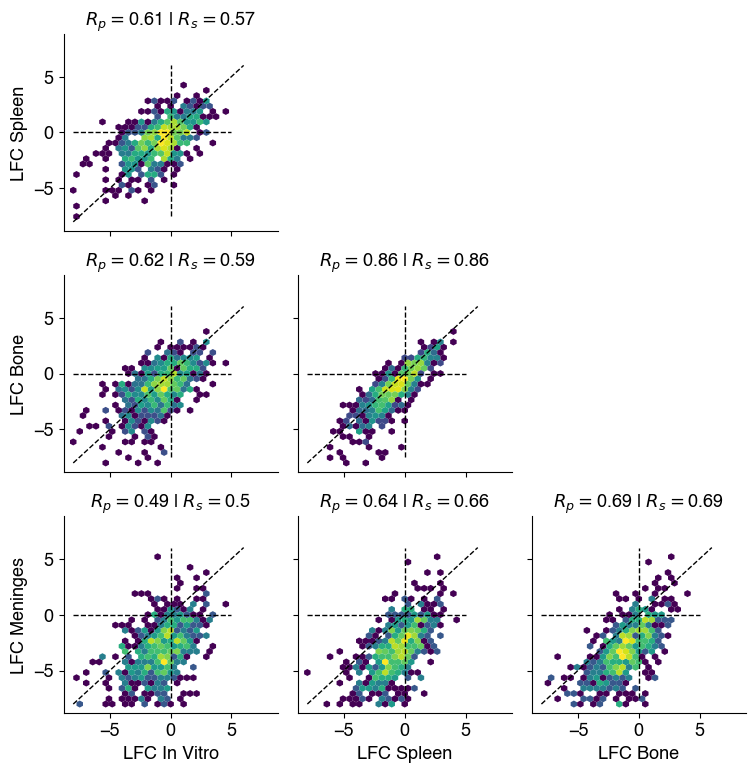

In [ ]:
KO = pd.read_csv('KO_LFC_FDR.csv')
KO = KO[KO['Input_median']>=100]

samples = ['LFC_median_d15', 'LFC_median_spleen', 'LFC_median_bonemarrow', 'LFC_median_meninges']

fig, ax = plt.subplots(4,4,figsize=(10,10), sharex=True, sharey=True)

palette = ['#F9CBA8', '#ED6A50', '#7284A1', 'lightgrey', 'darkslategray']


s_dict = {'LFC_median_d15': 'LFC In Vitro', 'LFC_median_spleen': 'LFC Spleen', 'LFC_median_bonemarrow': 'LFC Bone', 'LFC_median_meninges': 'LFC Meninges'}
for idx, samp in enumerate(samples):

    row = idx
    for idx2, samp2 in enumerate(samples):
        col = idx2
        ax[row][col].hexbin(KO[samp2], KO[samp], bins='log', gridsize=30, linewidth=0, extent = (-8, 8, -8, 8))

        ax[row][col].plot([0,0],[-7.5,6], linestyle='dashed', color='black', linewidth=1)
        ax[row][col].plot([-8,5],[0,0], linestyle='dashed', color='black', linewidth=1)
        ax[row][col].plot([-8,6],[-8,6], linestyle='dashed', color='black', linewidth=1)

        ax[row][0].set_ylabel(s_dict[samp], fontsize=13)
        ax[3][col].set_xlabel(s_dict[samp2], fontsize=13)
    #ax[idx//3][idx%3].set_xticklabels(['S', 'B', 'M'])
    #ax[idx//3][idx%3].set_yticklabels(['IV', 'S', 'B',])
    #ax[idx//3][idx%3].set_title(f'{gene}', fontsize=12)

        ax[row][col].spines[['top', 'right']].set_visible(False)

        ax[row][col].tick_params(axis='both', which='major', labelsize=13,)

        spear = np.round(scipy.stats.spearmanr(KO[samp2], KO[samp]).statistic, 2)
        pear = np.round(scipy.stats.pearsonr(KO[samp2], KO[samp]).statistic, 2)

        ax[row][col].set_title('$R_{p} = $' + f'{pear}' + ' | $R_{s} = $' + f'{spear}', fontsize=13)
  

fig.delaxes(ax[0][0])
fig.delaxes(ax[0][1])
fig.delaxes(ax[0][2])
fig.delaxes(ax[0][3])
fig.delaxes(ax[1][1])
fig.delaxes(ax[1][2])
fig.delaxes(ax[1][3])
fig.delaxes(ax[2][2])
fig.delaxes(ax[2][3])
fig.delaxes(ax[3][3])

fig.tight_layout()
#fig.savefig('figures/extended_fig_KO_correlations_UPDATED.pdf', transparent=True)

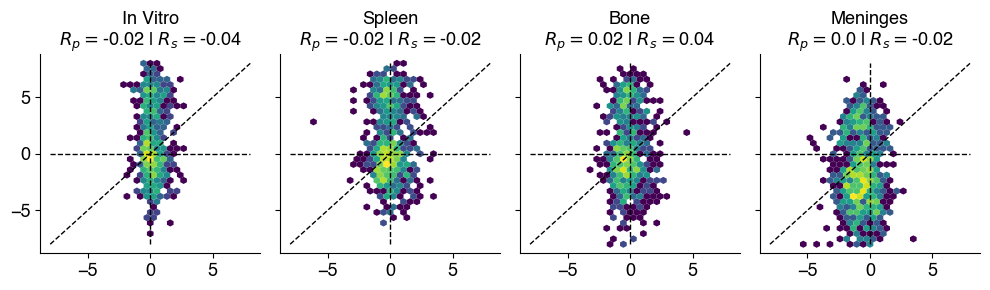

In [ ]:
BE = pd.read_csv('ABE_LFC_FDR_df.csv')
BE = BE[(BE['classification']=='targeting guide') & (BE['target_base_edit_perc']>=20)]
KO = pd.read_csv('KO_LFC_FDR.csv').rename(columns = {'sgrna':'gRNA_id', 'LFC_median_d15':'LFC_median_d15_KO', 'LFC_median_spleen':'LFC_median_spleen_KO', 'LFC_median_bonemarrow':'LFC_median_bonemarrow_KO', 'LFC_median_meninges':'LFC_median_meninges_KO'})

merged = pd.merge(KO, BE, on='gRNA_id')

samples_KO = ['LFC_median_d15_KO', 'LFC_median_spleen_KO', 'LFC_median_bonemarrow_KO', 'LFC_median_meninges_KO']
samples_BE = ['LFC_median_d15', 'LFC_median_spleen', 'LFC_median_bonemarrow', 'LFC_median_meninges']
names = ['In Vitro', 'Spleen', 'Bone', "Meninges"]

fig, ax = plt.subplots(1,4,figsize=(10,3), sharex=True, sharey=True)

for i in range(4):

    ax[i].hexbin(merged[samples_BE[i]], merged[samples_KO[i]], bins='log', gridsize=30, linewidth=0, extent = (-8, 8, -8, 8))
    ax[i].plot([0,0],[-8,8], linestyle='dashed', color='black', linewidth=1)
    ax[i].plot([-8,8],[0,0], linestyle='dashed', color='black', linewidth=1)
    ax[i].plot([-8,8],[-8,8], linestyle='dashed', color='black', linewidth=1)
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='both', which='major', labelsize=13,)

    spear = np.round(scipy.stats.spearmanr(merged[samples_BE[i]], merged[samples_KO[i]]).statistic, 2)
    pear = np.round(scipy.stats.pearsonr(merged[samples_BE[i]], merged[samples_KO[i]]).statistic, 2)

    ax[i].set_title(f'{names[i]}\n' + '$R_{p} = $' + f'{pear}' + ' | $R_{s} = $' + f'{spear}', fontsize=13)

    #ax[i].set_title(names[i], fontsize=14)
    
fig.tight_layout()
fig.savefig('figures/extended_BE_vs_KO_UPDATED.pdf', transparent=True)

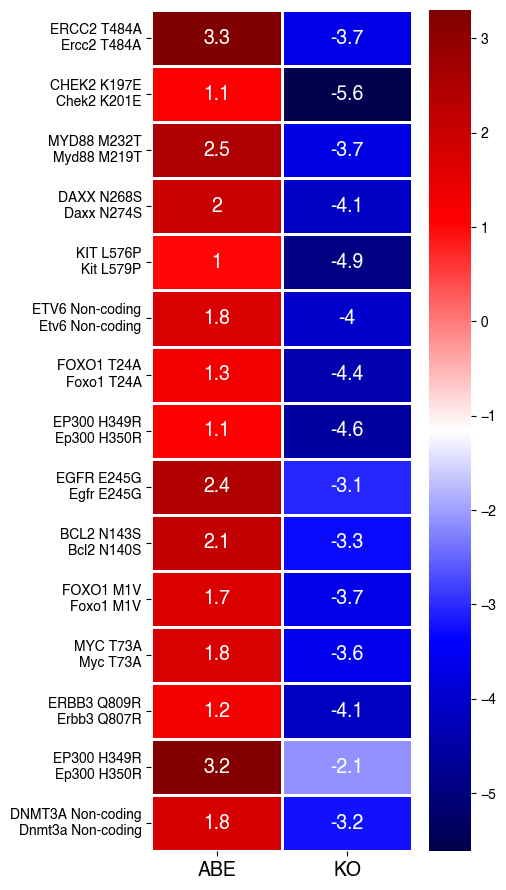

In [ ]:
#and compare top vs. bottom hits for some gRNAs in the spleen

delta = merged['LFC_median_spleen'] - merged['LFC_median_spleen_KO']
merged['delta_spleen'] = delta


merged2 = merged[merged['Input_median_x']>=100]
a0 = merged2[merged2['LFC_median_spleen']>=1]
a1 = a0.sort_values(by='delta_spleen', ascending=False)[:15]

fig, ax = plt.subplots(figsize=(5,9))


g = sns.heatmap(a1[['LFC_median_spleen', 'LFC_median_spleen_KO']], cmap='seismic', annot=True, annot_kws={'size':14}, linewidth=1, edgecolor='white')

name = []

for i, val in a1.iterrows():
    a = val['gene_name_h_x']
    b = val['HGVSp_h_x']
    c = val['gene_name_m_corrected_x']
    d = val['HGVSp_m_x']

    if type(b) != str:
        b = 'Non-coding'

    n = f'{a} {b}\n{c} {d}'
    name.append(n)

g.set_yticklabels(name, rotation=0)
g.set_xticklabels(['ABE', 'KO'], rotation=0, fontsize=14)
fig.tight_layout()

#fig.savefig('figures/heatmap_extended_KO_v_ABE.pdf', transparent=True)